# Why Subthreshold Noise Matters: Reproducing CMOS Inverter Physics
Author: Joshua JOHN
#### Reference
1. https://journals.aps.org/prx/pdf/10.1103/PhysRevX.11.031064


In [1]:
import yaml
import numpy as np
import h5py
import matplotlib.pyplot as plt

from sse_core.compiler.parser import SSEParser
from sse_core.compiler.builder import SSECompiler
from sse_core.compiler.units import E_CHARGE
from sse_core.solvers.gillespie import GillespieSolver
from sse_core.solvers.export import TelemetryExporter

In [2]:
# --- 1. Figure 11(a) parameters and circuit definition ---

# Thermal voltage used throughout the simulation.
V_THERMAL = 0.026  # V

# Figure 11(a) specifies q_e / q_T = 0.1, with q_T = 2 * C_o * V_T.
QE_OVER_QT = 0.1
C_O = E_CHARGE / (2.0 * V_THERMAL * QE_OVER_QT)

# Figure 11(a) does not separately constrain C_g.
# C_g is between regulated nodes and does not affect the static output-charge
# distribution, so we make the explicit neutral choice C_g = C_o.
C_G = C_O

I0 = 1.6e-7
MOS_THRESHOLD = 0.0
SLOPE_FACTOR = 1.0

# Panel parameters taken directly from Figure 11(a).
panel_specs = [
    {"vdd_over_vt": 0.0, "vin_over_vdd":  0.00},
    {"vdd_over_vt": 5.0, "vin_over_vdd":  0.00},
    {"vdd_over_vt": 5.0, "vin_over_vdd": -0.01},
    {"vdd_over_vt": 5.0, "vin_over_vdd": -0.20},
]

configs_fig11a = []

for spec in panel_specs:
    vdd = spec["vdd_over_vt"] * V_THERMAL

    # Vin/Vdd is undefined when Vdd = 0, so the equilibrium case uses Vin = 0.
    vin = spec["vin_over_vdd"] * vdd if vdd != 0.0 else 0.0

    configs_fig11a.append(
        {
            **spec,
            "vdd": vdd,
            "vss": -vdd,
            "vin": vin,
        }
    )

results_files = []

base_yaml_str = f"""schema_version: "1.0.0"

simulation:
  solver: "gillespie"
  t_finish: 5.0e-7
  v_th: {V_THERMAL:.17g}
  seed: 999

nodes:
  free:
    - name: "out"

  regulated:
    - name: "vdd"
      type: "constant"
      value: 0.0

    - name: "vin"
      type: "constant"
      value: 0.0

    - name: "vss"
      type: "constant"
      value: 0.0

components:
  # pMOS gate-body capacitance
  - type: "capacitor"
    name: "C_gate_p"
    terminals: ["vin", "vdd"]
    specs: {{capacitance: {C_G:.17g}}}

  # nMOS gate-body capacitance
  - type: "capacitor"
    name: "C_gate_n"
    terminals: ["vin", "vss"]
    specs: {{capacitance: {C_G:.17g}}}

  # pMOS output capacitance
  - type: "capacitor"
    name: "C_out_p"
    terminals: ["out", "vdd"]
    specs: {{capacitance: {C_O:.17g}}}

  # nMOS output capacitance
  - type: "capacitor"
    name: "C_out_n"
    terminals: ["out", "vss"]
    specs: {{capacitance: {C_O:.17g}}}

  - type: "p_channel_mosfet"
    name: "M_pullup"
    terminals:
      drain: "out"
      gate: "vin"
      source: "vdd"
      bulk: "vdd"
    specs:
      I0: {I0:.17g}
      VT: {MOS_THRESHOLD:.17g}
      n: {SLOPE_FACTOR:.17g}

  - type: "n_channel_mosfet"
    name: "M_pulldown"
    terminals:
      drain: "out"
      gate: "vin"
      source: "vss"
      bulk: "vss"
    specs:
      I0: {I0:.17g}
      VT: {MOS_THRESHOLD:.17g}
      n: {SLOPE_FACTOR:.17g}
"""

In [3]:
# --- 1a. Verify the Figure 11(a) configuration ---

qe_over_qt_actual = E_CHARGE / (2.0 * C_O * V_THERMAL)

assert np.isclose(
    qe_over_qt_actual,
    QE_OVER_QT,
    rtol=1e-12,
    atol=0.0,
)

netlist_check = yaml.safe_load(base_yaml_str)

capacitors = {
    component["name"]: component
    for component in netlist_check["components"]
    if component["type"] == "capacitor"
}

assert capacitors["C_gate_p"]["terminals"] == ["vin", "vdd"]
assert capacitors["C_gate_n"]["terminals"] == ["vin", "vss"]
assert capacitors["C_out_p"]["terminals"] == ["out", "vdd"]
assert capacitors["C_out_n"]["terminals"] == ["out", "vss"]

assembly_check = SSECompiler.compile_string(base_yaml_str)

# The free output node must see a total capacitance of 2*C_o.
compiled_total_output_capacitance = 1.0 / assembly_check.C_inv[0, 0]

assert np.isclose(
    compiled_total_output_capacitance,
    2.0 * C_O,
    rtol=1e-12,
    atol=0.0,
)

# Check the coupling of the output node to the regulated nodes.
cx_by_node = dict(
    zip(assembly_check.regulated_names, assembly_check.Cx[0])
)

assert np.isclose(cx_by_node["vdd"], -C_O, rtol=1e-12, atol=0.0)
assert np.isclose(cx_by_node["vss"], -C_O, rtol=1e-12, atol=0.0)
assert cx_by_node["vin"] == 0.0

print(f"V_T                 = {V_THERMAL * 1e3:.3f} mV")
print(f"C_o                 = {C_O * 1e18:.6f} aF")
print(f"Total output C      = {2.0 * C_O * 1e18:.6f} aF")
print(f"q_e / q_T           = {qe_over_qt_actual:.6f}")
print()
print("Figure 11(a) cases:")

for index, cfg in enumerate(configs_fig11a, start=1):
    print(
        f"Panel {index}: "
        f"Vdd/VT={cfg['vdd_over_vt']:.1f}, "
        f"Vin/Vdd={cfg['vin_over_vdd']:.2f}, "
        f"Vdd={cfg['vdd']:.6f} V, "
        f"Vin={cfg['vin']:.6f} V"
    )

V_T                 = 26.000 mV
C_o                 = 30.811089 aF
Total output C      = 61.622178 aF
q_e / q_T           = 0.100000

Figure 11(a) cases:
Panel 1: Vdd/VT=0.0, Vin/Vdd=0.00, Vdd=0.000000 V, Vin=0.000000 V
Panel 2: Vdd/VT=5.0, Vin/Vdd=0.00, Vdd=0.130000 V, Vin=0.000000 V
Panel 3: Vdd/VT=5.0, Vin/Vdd=-0.01, Vdd=0.130000 V, Vin=-0.001300 V
Panel 4: Vdd/VT=5.0, Vin/Vdd=-0.20, Vdd=0.130000 V, Vin=-0.026000 V


In [12]:
import gc
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np

from sse_core.compiler.builder import SSECompiler
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.units import E_CHARGE
from sse_core.devices.semiconductor import mosfet_rates
from sse_core.solvers.gillespie import GillespieSolver


# Reuse the quantities defined in the previous cells.
Q_T = 2.0 * C_O * V_THERMAL

# Figure 11(a) uses n = 1. I0 and Vth determine only the time scale
#
#     t0 = (qe / I0) exp[Vth / (n VT)].
#
# Choose convenient values while preserving the paper's stationary
# distribution.
SLOPE_FACTOR = 1.0
V_THRESHOLD = 4.0 * V_THERMAL
T0 = 1.0e-9

I0 = (
    E_CHARGE
    / T0
    * np.exp(
        V_THRESHOLD
        / (SLOPE_FACTOR * V_THERMAL)
    )
)

# Cg contributes to the regulated-node energy but not to the
# output-charge dynamics for fixed Vin, Vdd and Vss. Using Cg = Co
# keeps the capacitance matrix well conditioned.
C_g = C_O

MAX_EVENTS = 400_000
BURN_FRACTION = 0.15
SIMULATION_LIMIT = 1.0e6 * T0
BASE_SEED = 11_000


# Preflight check: at mirrored biases, the pMOS rates must be the
# direction-reversed nMOS rates.
test_voltage = 2.0 * V_THERMAL

n_forward, n_reverse = mosfet_rates(
    test_voltage,
    test_voltage,
    I0,
    +V_THRESHOLD,
    SLOPE_FACTOR,
    V_THERMAL,
    False,
)

p_forward, p_reverse = mosfet_rates(
    -test_voltage,
    -test_voltage,
    I0,
    -V_THRESHOLD,
    SLOPE_FACTOR,
    V_THERMAL,
    True,
)

np.testing.assert_allclose(
    [n_forward, n_reverse],
    [p_reverse, p_forward],
    rtol=1.0e-12,
    atol=0.0,
)

print(f"Chosen t0           = {T0:.3e} s")
print(f"Chosen I0           = {I0:.6e} A")
print(f"Events per panel    = {MAX_EVENTS:,}")
print("MOS mirror check    = passed")

Chosen t0           = 1.000e-09 s
Chosen I0           = 8.747588e-09 A
Events per panel    = 400,000
MOS mirror check    = passed


In [13]:
FIGURE_11A_CASES = [
    {
        "panel": 1,
        "vdd_over_vt": 0.0,
        "vin_over_vdd": 0.00,
    },
    {
        "panel": 2,
        "vdd_over_vt": 5.0,
        "vin_over_vdd": 0.00,
    },
    {
        "panel": 3,
        "vdd_over_vt": 5.0,
        "vin_over_vdd": -0.01,
    },
    {
        "panel": 4,
        "vdd_over_vt": 5.0,
        "vin_over_vdd": -0.20,
    },
]


def expand_case(case):
    """Convert the dimensionless Figure 11(a) settings to volts."""

    vdd = case["vdd_over_vt"] * V_THERMAL
    vss = -vdd

    # Avoid calculating 0 / 0 for the unpowered panel.
    vin = (
        0.0
        if vdd == 0.0
        else case["vin_over_vdd"] * vdd
    )

    return {
        **case,
        "vdd": vdd,
        "vss": vss,
        "vin": vin,
    }


FIGURE_11A_CASES = [
    expand_case(case)
    for case in FIGURE_11A_CASES
]


def deterministic_native_charge(case):
    """
    Return the deterministic output charge in simulator-native
    electron-count units.

    The paper uses physical output charge q. The simulator stores excess
    electron count, whose polarity is inverted:

        q_physical = -qe * q_native.

    No sign transformation is applied to the simulated data; the minus
    sign appears only when translating the paper's deterministic result
    into the native convention.
    """

    vdd = case["vdd"]
    vss = case["vss"]
    vin = case["vin"]

    alpha_n = np.exp(
        (vin - vss)
        / (SLOPE_FACTOR * V_THERMAL)
    )

    alpha_p = np.exp(
        (vdd - vin)
        / (SLOPE_FACTOR * V_THERMAL)
    )

    gamma_0 = np.exp(
        -(vdd - vss)
        / (2.0 * V_THERMAL)
    )

    # Deterministic limit of Eq. (122): a = b = 0.
    coefficient_a = alpha_p * gamma_0
    coefficient_b = alpha_n - alpha_p
    coefficient_c = -alpha_n * gamma_0

    discriminant = (
        coefficient_b**2
        - 4.0
        * coefficient_a
        * coefficient_c
    )

    roots = np.array(
        [
            (
                -coefficient_b
                + np.sqrt(discriminant)
            )
            / (2.0 * coefficient_a),
            (
                -coefficient_b
                - np.sqrt(discriminant)
            )
            / (2.0 * coefficient_a),
        ]
    )

    positive_roots = roots[
        np.isfinite(roots)
        & (roots > 0.0)
    ]

    if len(positive_roots) != 1:
        raise RuntimeError(
            f"Expected one positive deterministic root; got {roots}."
        )

    x = positive_roots[0]

    physical_charge_over_qe = (
        Q_T
        / E_CHARGE
        * np.log(x)
    )

    return -physical_charge_over_qe


def build_inverter_yaml(case, seed):
    """
    Build the four-conductor inverter of the paper:

        free:      out
        regulated: vin, vdd, vss

    The output has total capacitance 2 Co.
    """

    return dedent(
        f"""
        schema_version: "1.0.0"

        simulation:
          solver: "gillespie"
          t_finish: {SIMULATION_LIMIT:.17e}
          v_th: {V_THERMAL:.17e}
          seed: {seed}

        nodes:
          free:
            - name: "out"
              initial_charge: 0

          regulated:
            - name: "vin"
              type: "constant"
              value: {case["vin"]:.17e}

            - name: "vdd"
              type: "constant"
              value: {case["vdd"]:.17e}

            - name: "vss"
              type: "constant"
              value: {case["vss"]:.17e}

        components:
          - type: "capacitor"
            name: "C_out_dd"
            terminals: ["out", "vdd"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "C_out_ss"
            terminals: ["out", "vss"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "C_gate_dd"
            terminals: ["vin", "vdd"]
            specs:
              capacitance: {C_g:.17e}

          - type: "capacitor"
            name: "C_gate_ss"
            terminals: ["vin", "vss"]
            specs:
              capacitance: {C_g:.17e}

          - type: "n_channel_mosfet"
            name: "NMOS"
            terminals:
              drain: "out"
              gate: "vin"
              source: "vss"
              bulk: "vss"
            specs:
              I0: {I0:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "PMOS"
            terminals:
              drain: "out"
              gate: "vin"
              source: "vdd"
              bulk: "vdd"
            specs:
              I0: {I0:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}
        """
    )

In [14]:
def regulated_voltage_vector(
    parsed_netlist,
    assembly,
):
    values_by_name = {
        node.name: node.value
        for node in parsed_netlist.nodes.regulated
    }

    return np.asarray(
        [
            values_by_name[name]
            for name in assembly.regulated_names
        ],
        dtype=np.float64,
    )


def run_figure_11a_case(case):
    yaml_text = build_inverter_yaml(
        case,
        seed=BASE_SEED + case["panel"],
    )

    parsed_netlist = SSEParser.parse_string(
        yaml_text
    )

    assembly = SSECompiler.compile_string(
        yaml_text
    )

    solver = GillespieSolver(
        parsed_netlist,
        assembly,
    )

    vr = regulated_voltage_vector(
        parsed_netlist,
        assembly,
    )

    deterministic_charge = (
        deterministic_native_charge(case)
    )

    # Starting near the deterministic solution reduces the discarded
    # equilibration period, but does not constrain the trajectory.
    q_initial = np.array(
        [
            int(
                np.rint(
                    deterministic_charge
                )
            )
        ],
        dtype=np.int64,
    )

    full_history = solver.simulate(
        q_init=q_initial,
        vr=vr,
        max_steps=MAX_EVENTS,
    )

    number_of_events = len(
        full_history["events"]["time"]
    )

    if number_of_events < 10_000:
        raise RuntimeError(
            f"Panel {case['panel']} generated only "
            f"{number_of_events:,} events."
        )

    # The event ledger is essential for verification, but Figure 11(a)
    # needs only the residence times and charge states. Compact each run
    # before starting the next panel.
    compact_history = {
        "time": full_history["time"].copy(),
        "charge": full_history["charge"].copy(),
        "termination_reason": full_history[
            "termination_reason"
        ],
    }

    duration_over_t0 = (
        compact_history["time"][-1]
        / T0
    )

    print(
        f"Panel {case['panel']}: "
        f"{number_of_events:,} events, "
        f"duration/t0={duration_over_t0:,.1f}, "
        f"q_init={q_initial[0]}, "
        f"q_det={deterministic_charge:.3f}"
    )

    del full_history
    gc.collect()

    return {
        "case": case,
        "history": compact_history,
        "q_deterministic_native": (
            deterministic_charge
        ),
    }


figure_11a_runs = [
    run_figure_11a_case(case)
    for case in FIGURE_11A_CASES
]

Panel 1: 400,000 events, duration/t0=100,073.9, q_init=0, q_det=-0.000
Panel 2: 400,000 events, duration/t0=1,321.6, q_init=0, q_det=-0.000
Panel 3: 400,000 events, duration/t0=1,278.2, q_init=-27, q_det=-26.523
Panel 4: 400,000 events, duration/t0=494.3, q_init=-49, q_det=-48.546


In [15]:
def residence_time_distribution(
    history,
    burn_fraction=BURN_FRACTION,
):
    """
    Compute the stationary discrete probability mass from Gillespie
    residence times.

    State charge[i] occupies the interval

        [time[i], time[i + 1]).

    Counting recorded states without weighting would bias the result
    toward states with high escape rates.
    """

    time = np.asarray(
        history["time"],
        dtype=np.float64,
    )

    native_charge = np.asarray(
        history["charge"][:-1, 0],
        dtype=np.int64,
    )

    interval_start = time[:-1]
    interval_end = time[1:]

    burn_time = (
        time[0]
        + burn_fraction
        * (time[-1] - time[0])
    )

    residence_time = np.maximum(
        0.0,
        interval_end
        - np.maximum(
            interval_start,
            burn_time,
        ),
    )

    keep = residence_time > 0.0

    native_charge = native_charge[keep]
    residence_time = residence_time[keep]

    states, inverse = np.unique(
        native_charge,
        return_inverse=True,
    )

    state_time = np.bincount(
        inverse,
        weights=residence_time,
    )

    probability = (
        state_time
        / np.sum(state_time)
    )

    return states, probability


for run in figure_11a_runs:
    states, probability = (
        residence_time_distribution(
            run["history"]
        )
    )

    run["states"] = states
    run["probability"] = probability

    print(
        f"Panel {run['case']['panel']}: "
        f"normalization={probability.sum():.12f}, "
        f"range=[{states.min()}, {states.max()}]"
    )

Panel 1: normalization=1.000000000000, range=[-14, 15]
Panel 2: normalization=1.000000000000, range=[-48, 49]
Panel 3: normalization=1.000000000000, range=[-55, 48]
Panel 4: normalization=1.000000000000, range=[-64, -34]


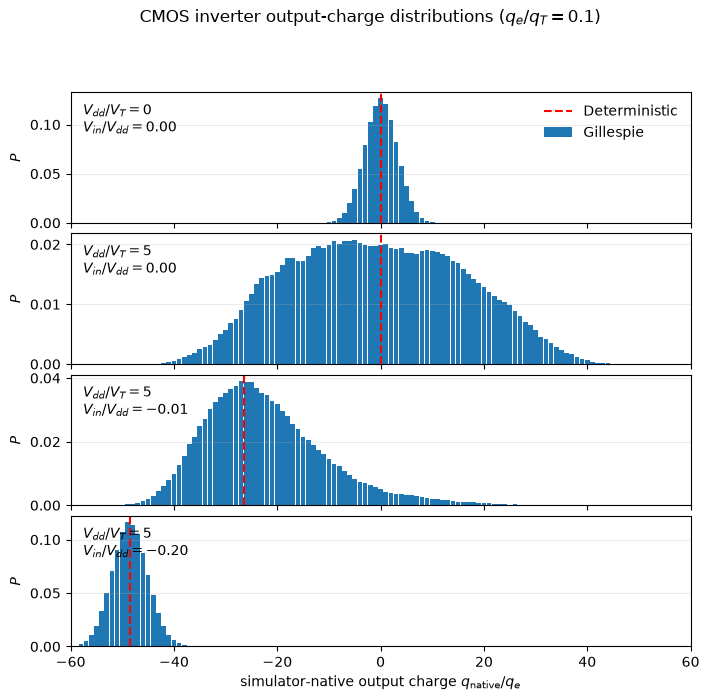

In [18]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    sharex=True,
    figsize=(8.0, 7.2),
    gridspec_kw={
        "hspace": 0.08,
    },
)

for axis, run in zip(
    axes,
    figure_11a_runs,
):
    case = run["case"]
    states = run["states"]
    probability = run["probability"]

    axis.bar(
        states,
        probability,
        width=0.92,
        align="center",
        label="Gillespie",
    )

    axis.axvline(
        run["q_deterministic_native"],
        color = 'red',
        linestyle="--",
        linewidth=1.5,
        label="Deterministic",
    )

    axis.text(
        0.02,
        0.92,
        (
            rf"$V_{{dd}}/V_T={case['vdd_over_vt']:.0f}$"
            "\n"
            rf"$V_{{in}}/V_{{dd}}="
            rf"{case['vin_over_vdd']:.2f}$"
        ),
        transform=axis.transAxes,
        va="top",
        ha="left",
    )

    axis.set_ylabel(r"$P$")
    axis.set_ylim(bottom=0.0)
    axis.grid(
        axis="y",
        alpha=0.25,
    )

axes[0].legend(
    loc="upper right",
    frameon=False,
)

axes[-1].set_xlabel(
    r"simulator-native output charge "
    r"$q_{\mathrm{native}}/q_e$"
)

axes[-1].set_xlim(
    -60,
    60,
)

fig.suptitle(
    r"CMOS inverter output-charge distributions "
    r"($q_e/q_T=0.1$)",
    y=0.995,
)

plt.show()